=== PART 1: TRAINING ON SOURCE LOCATION (KOLKATA) ===
Base Model Trained Successfully.

=== PART 2: TRANSFER LEARNING TO TARGET (IIT GUWAHATI) ===

=== PART 3: CONTINUAL LEARNING (FINE-TUNING) ===
Fine-Tuning Complete (Adjusted to local IITG baseline).

=== PART 4: EVALUATION & VISUALIZATION ===
Old Model Cosine Similarity (Feb-Dec): 76.68%
NEW Fine-Tuned Cosine Similarity (Feb-Dec): 76.87%
Final results saved to Final_FineTuned_IITG_Predictions.csv


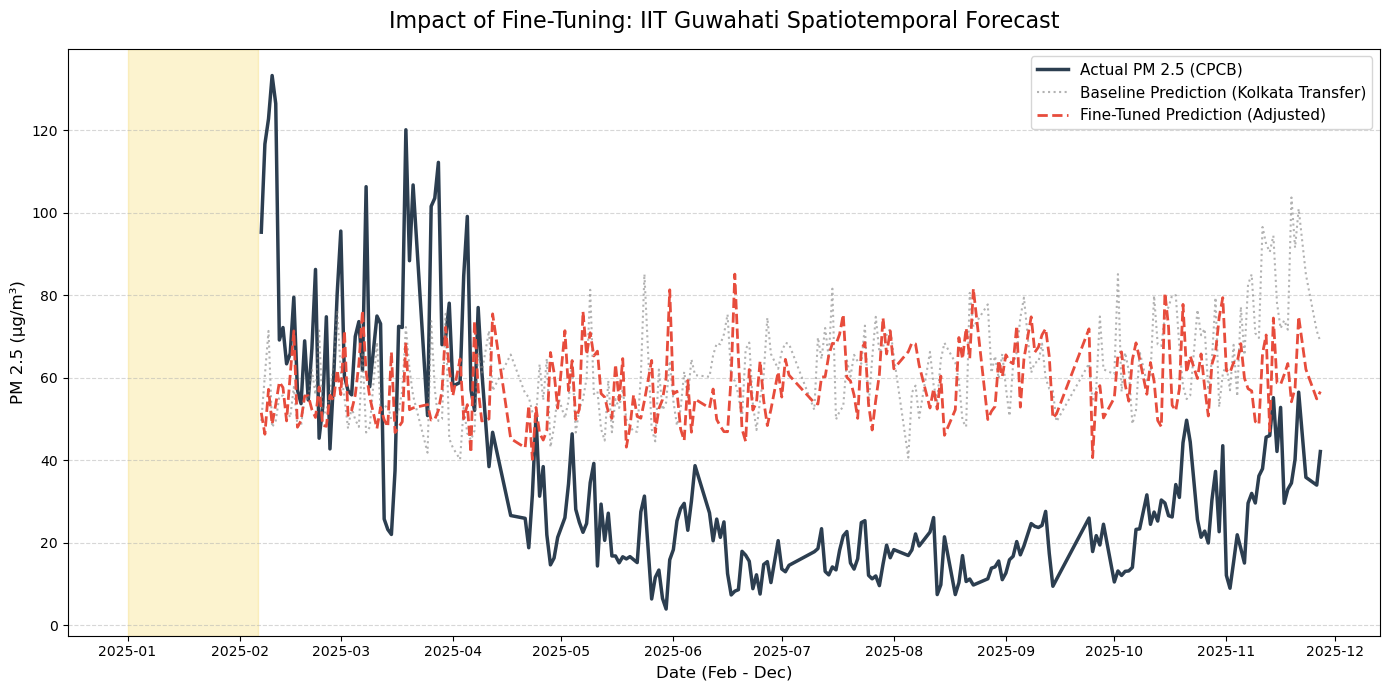

In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt
import numpy as np
import warnings

# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore')

print("=== PART 1: TRAINING ON SOURCE LOCATION (KOLKATA) ===")

# 1. Load the flattened features for Kolkata
train_features = pd.read_csv("XGBoost_Ready_Kolkata_JU_Dataset.csv")

# 2. Load the historical PM 2.5 targets for Kolkata 
train_targets = pd.read_csv("Processed_Daily_PM25_Kolkata_ju_2025.csv") 

# Merge them together based on the date
train_features['Date_Str'] = train_features['Date_Str'].astype(str)
train_targets['Date'] = pd.to_datetime(train_targets['Date']).astype(str)

training_data = pd.merge(train_features, train_targets, left_on='Date_Str', right_on='Date', how='inner')

# Define inputs (X) and output (y)
X_kol = training_data.drop(columns=['Date_Str', 'Date', 'PM2.5'])
y_kol = training_data['PM2.5']

# Split the Kolkata data 
X_train, X_test, y_train, y_test = train_test_split(X_kol, y_kol, test_size=0.2, random_state=42)

# Initialize and Train the Base XGBoost Regressor
base_model = xgb.XGBRegressor(
    n_estimators=500,        
    learning_rate=0.05,      
    max_depth=6,             
    subsample=0.8,           
    colsample_bytree=0.8,    
    random_state=42,
    early_stopping_rounds=50 
)

base_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print("Base Model Trained Successfully.")


print("\n=== PART 2: TRANSFER LEARNING TO TARGET (IIT GUWAHATI) ===")

# Load IIT Guwahati's features
predict_features = pd.read_csv("XGBoost_Ready_IITG_Dataset.csv")
X_iitg_full = predict_features.drop(columns=['Date_Str'])

# Make the baseline prediction!
initial_iitg_predictions = base_model.predict(X_iitg_full)

# Create a dataframe for the initial predictions
df_pred = pd.DataFrame({
    'Date': pd.to_datetime(predict_features['Date_Str']),
    'Old_Prediction': initial_iitg_predictions
})

# Load the Actual IIT Guwahati Data (Try both excel and csv reading methods safely)
try:
    df_actual = pd.read_excel("Processed_Daily_PM2.5_IIT_G_2025.xls")
except:
    df_actual = pd.read_csv("Processed_Daily_PM2.5_IIT_G_2025.xls")

df_actual['Date'] = pd.to_datetime(df_actual['Date'], format='%d-%m-%Y', errors='coerce')

# Merge predictions with actuals
merged_iitg = pd.merge(df_pred, df_actual, on='Date', how='inner').dropna()
merged_iitg = merged_iitg.sort_values('Date')


print("\n=== PART 3: CONTINUAL LEARNING (FINE-TUNING) ===")

# We will use the first 30 days (January) to "teach" the model the Guwahati baseline
# We will test the improvement on Day 31 onwards (Feb - Dec)
cutoff_days = 30

X_tune = X_iitg_full.iloc[:cutoff_days]
y_tune = merged_iitg['PM2.5'].iloc[:cutoff_days] 

X_test_new = X_iitg_full.iloc[cutoff_days:len(merged_iitg)]
y_test_new = merged_iitg['PM2.5'].iloc[cutoff_days:] 

# Create the Fine-Tuning Model Configuration
fine_tuned_model = xgb.XGBRegressor(
    n_estimators=50,         # Add only 50 new trees
    learning_rate=0.01,      # Low learning rate for gentle baseline shifting
    max_depth=6,             
    random_state=42
)

# Train the new trees ON TOP OF the old model using 'xgb_model=base_model'
fine_tuned_model.fit(X_tune, y_tune, xgb_model=base_model)
print("Fine-Tuning Complete (Adjusted to local IITG baseline).")


print("\n=== PART 4: EVALUATION & VISUALIZATION ===")

# Predict the rest of the year using the upgraded model
new_predictions = fine_tuned_model.predict(X_test_new)

# Calculate Accuracy Metrics on the Unseen Data (Feb-Dec)
old_preds_test_period = merged_iitg['Old_Prediction'].iloc[cutoff_days:]

old_cos_sim = (1 - cosine(y_test_new, old_preds_test_period)) * 100
new_cos_sim = (1 - cosine(y_test_new, new_predictions)) * 100

print(f"Old Model Cosine Similarity (Feb-Dec): {old_cos_sim:.2f}%")
print(f"NEW Fine-Tuned Cosine Similarity (Feb-Dec): {new_cos_sim:.2f}%")

# Save final results to CSV
final_output = merged_iitg.iloc[cutoff_days:].copy()
final_output['Fine_Tuned_Prediction'] = new_predictions
final_output.to_csv("Final_FineTuned_IITG_Predictions.csv", index=False)
print("Final results saved to Final_FineTuned_IITG_Predictions.csv")

# Plotting the improvement
plt.figure(figsize=(14, 7))

# 1. Plot Actual PM 2.5
plt.plot(merged_iitg['Date'].iloc[cutoff_days:], y_test_new, 
         label='Actual PM 2.5 (CPCB)', color='#2c3e50', linewidth=2.5)

# 2. Plot Initial Transfer Prediction
plt.plot(merged_iitg['Date'].iloc[cutoff_days:], old_preds_test_period, 
         label='Baseline Prediction (Kolkata Transfer)', color='gray', alpha=0.6, linestyle=':')

# 3. Plot Fine-Tuned Prediction
plt.plot(merged_iitg['Date'].iloc[cutoff_days:], new_predictions, 
         label='Fine-Tuned Prediction (Adjusted)', color='#e74c3c', linewidth=2, linestyle='--')

plt.title('Impact of Fine-Tuning: IIT Guwahati Spatiotemporal Forecast', fontsize=16, pad=15)
plt.ylabel('PM 2.5 (µg/m³)', fontsize=12)
plt.xlabel('Date (Feb - Dec)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Highlight the fine-tuning training period (January) visually 
plt.axvspan(merged_iitg['Date'].iloc[0], merged_iitg['Date'].iloc[cutoff_days-1], 
            color='#f1c40f', alpha=0.2, label='Fine-Tuning Period (Used for training)')

plt.tight_layout()
plt.savefig("IITG_FineTuning_Results.png", dpi=300)
plt.show()